#Chart

In [2]:
import serial, re, time

PORT        = "/dev/ttyUSB0"
BAUD        = 9600
COLLECT_SEC = 30          

RE_STATUS = re.compile(
    r"\[MAX\]\s+HR=(\d+)\s+bpm\s+SpO2=(\d+)%\s+finger=(\w+)"
)

times, hr_vals, spo2_vals = [], [], []

ser = serial.Serial(PORT, BAUD, timeout=1)
ser.reset_input_buffer()
t0 = time.time()
print(f"Recording {COLLECT_SEC}s — place finger on sensor...")

while (time.time() - t0) < COLLECT_SEC:
    line = ser.readline().decode("utf-8", errors="replace").strip()
    m = RE_STATUS.search(line)
    if m:
        hr, spo2, finger = int(m.group(1)), int(m.group(2)), m.group(3)
        t = round(time.time() - t0, 2)
        times.append(t)
        hr_vals.append(hr)
        spo2_vals.append(spo2)
        print(f"  t={t:5.1f}s  HR={hr:3d} bpm  SpO2={spo2:3d}%  finger={finger}")

ser.close()
print(f"\nDone — {len(times)} readings collected.")

Recording 30s — place finger on sensor...
  t=  1.1s  HR=  0 bpm  SpO2=  0%  finger=NO
  t=  6.8s  HR=  0 bpm  SpO2=  0%  finger=NO
  t= 12.4s  HR=  0 bpm  SpO2=  0%  finger=NO
  t= 18.1s  HR= 62 bpm  SpO2= 93%  finger=YES
  t= 23.8s  HR= 73 bpm  SpO2= 92%  finger=YES
  t= 29.5s  HR=137 bpm  SpO2= 95%  finger=YES

Done — 6 readings collected.


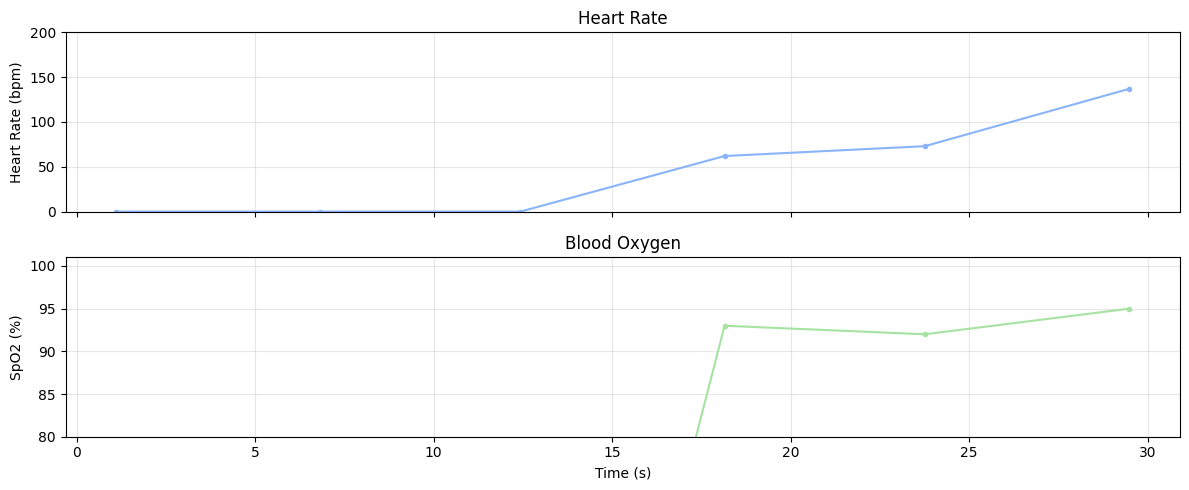

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1.plot(times, hr_vals, color="#89b4fa", linewidth=1.5, marker="o", markersize=3)
ax1.set_ylabel("Heart Rate (bpm)")
ax1.set_title("Heart Rate")
ax1.set_ylim(0, 200)
ax1.grid(alpha=0.3)

ax2.plot(times, spo2_vals, color="#a6e3a1", linewidth=1.5, marker="o", markersize=3)
ax2.set_ylabel("SpO2 (%)")
ax2.set_title("Blood Oxygen")
ax2.set_xlabel("Time (s)")
ax2.set_ylim(80, 101)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()